<a href="https://colab.research.google.com/github/keil4ni/151r-proj/blob/casey/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("short_video_engagement.csv")
print(df.head())

   views  likes  comments  watch_duration  shares  title_length  \
0     47     11         4       74.340181       0            18   
1     55     14         2       86.547617       1            89   
2     42      8         1       54.707006       0            97   
3     52     11         3       79.213670       1            73   
4     58      5         3       48.211898       0            62   

   description_length  edge_intensity  color_histogram  spectral_entropy  \
0                 878        0.436661         0.676880          0.524134   
1                  46        0.269328         0.376931          0.519303   
2                 568        0.136938         0.810070          0.636209   
3                 430        0.376898         0.873595          0.428849   
4                 339        0.380682         0.357269          0.580513   

   audio_intensity  engagement_score  
0         0.224402                 1  
1         0.044861                 1  
2         0.369313     

In [4]:
df

,views,likes,comments,watch_duration,shares,title_length,description_length,edge_intensity,color_histogram,spectral_entropy,audio_intensity,engagement_score
0,47,11,4,74.340181,0,18,878,0.436661,0.676880,0.524134,0.224402,1
1,55,14,2,86.547617,1,89,46,0.269328,0.376931,0.519303,0.044861,1
2,42,8,1,54.707006,0,97,568,0.136938,0.810070,0.636209,0.369313,1
3,52,11,3,79.213670,1,73,430,0.376898,0.873595,0.428849,0.220346,1
4,58,5,3,48.211898,0,62,339,0.380682,0.357269,0.580513,0.350787,0
...,...,...,...,...,...,...,...,...,...,...,...,...
17649,57,5,1,68.681723,0,81,536,0.015509,0.678075,0.727737,0.582059,0
17650,59,16,2,39.623208,2,50,659,0.434292,0.584963,0.421625,0.250497,1
17651,65,11,2,100.000000,0,69,422,0.678723,0.900423,0.653774,0.730677,0
17652,56,7,2,55.294093,0,39,325,0.045493,0.354416,0.479303,0.746592,0


In [6]:
df.columns

Index(['views', 'likes', 'comments', 'watch_duration', 'shares',
       'title_length', 'description_length', 'edge_intensity',
       'color_histogram', 'spectral_entropy', 'audio_intensity',
       'engagement_score'],
      dtype='object')

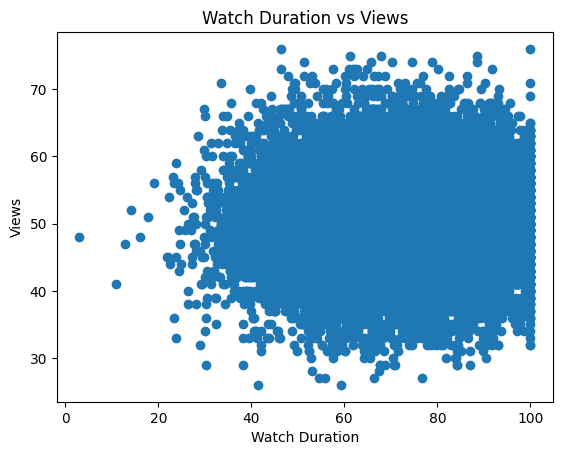

In [8]:
plt.scatter(df['watch_duration'], df['views'])
plt.xlabel('Watch Duration')
plt.ylabel('Views')
plt.title('Watch Duration vs Views')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[['watch_duration']]
y = df['views']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 0.0008399551166852902
Intercept: 49.901132183202385


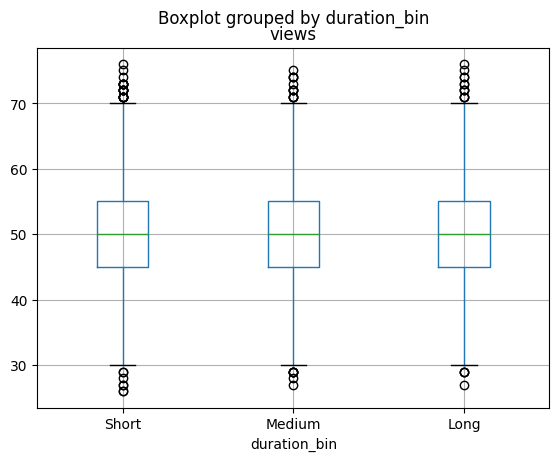

In [14]:
df['duration_bin'] = pd.qcut(
    df['watch_duration'],
    q=3,
    labels=['Short', 'Medium', 'Long']
)

df.boxplot(column='views', by='duration_bin')
plt.show()


In [15]:
df['duration_bin'] = pd.cut(
    df['watch_duration'],
    bins=[0, 60, 90, float('inf')],
    labels=['Short (≤60s)', 'Medium (60–90s)', 'Long (>90s)'],
    right=True
)

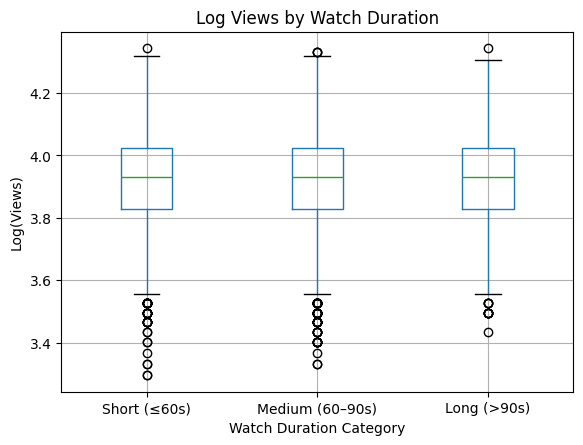

In [16]:
import numpy as np
import matplotlib.pyplot as plt

df['log_views'] = np.log1p(df['views'])

df.boxplot(column='log_views', by='duration_bin')
plt.xlabel('Watch Duration Category')
plt.ylabel('Log(Views)')
plt.title('Log Views by Watch Duration')
plt.suptitle('')
plt.show()


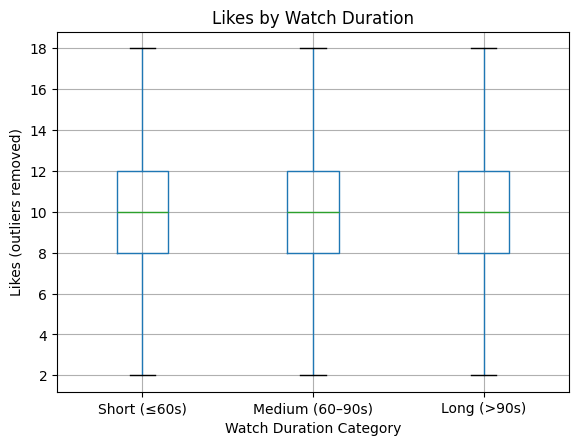

In [18]:
import numpy as np
import matplotlib.pyplot as plt

df['log_likes'] = np.log1p(df['likes'])

df.boxplot(
    column='likes',
    by='duration_bin',
    showfliers=False
)
plt.xlabel('Watch Duration Category')
plt.ylabel('Likes (outliers removed)')
plt.title('Likes by Watch Duration')
plt.suptitle('')
plt.show()
